Setting up data

In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = 'shubh5106'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_6af55654693f304487af44b23538d3dc'

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahmoudreda55/satellite-image-classification")

print("Path to dataset files:", path)

100%|██████████| 21.8M/21.8M [00:01<00:00, 15.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

drive_path = '/content/drive/MyDrive/Satellite_Project'
os.makedirs(drive_path, exist_ok=True)

zip_path = os.path.join(drive_path, 'satellite_dataset.zip')
print("Zipping and transferring data to Google Drive... This will take a couple of minutes.")

# Correctly use shutil.make_archive:
# The first argument should be the base name of the archive (without extension).
# The second argument is the format (e.g., 'zip').
# The third argument is the root directory to archive (the 'path' variable from the kagglehub download).
shutil.make_archive(os.path.splitext(zip_path)[0], 'zip', path)

Zipping and transferring data to Google Drive... This will take a couple of minutes.


'/content/drive/MyDrive/Satellite_Project/satellite_dataset.zip'

In [ ]:
# Verify the zip file exists in Google Drive before unzipping
!ls -lh /content/drive/MyDrive/Satellite_Project/

# Attempt to unzip the file
# If this still fails, consider copying the zip to /tmp first:
# !cp /content/drive/MyDrive/Satellite_Project/satellite_dataset.zip /tmp/
# !unzip -q /tmp/satellite_dataset.zip -d /content/drive/MyDrive/Satellite_Project/extracted_data
!unzip -q /content/drive/MyDrive/Satellite_Project/satellite_dataset.zip -d /content/drive/MyDrive/Satellite_Project/extracted_data

total 22M
-rw------- 1 root root 22M May 23 07:33 satellite_dataset.zip


In [ ]:
import os
import shutil

# Creating directories
root_dir = '/content/drive/MyDrive/Satellite_Project/extracted_data'

# Remove existing root_dir if it exists to ensure a clean start
if os.path.exists(root_dir):
  shutil.rmtree(root_dir)

def create_train_val_dirs(base_path):
  # Create the root directory if it doesn't exist
  os.makedirs(base_path, exist_ok=True)

  train_dir = os.path.join(base_path, 'train')
  validat_dir = os.path.join(base_path, 'val')

  # Create train and validation root directories
  os.makedirs(train_dir, exist_ok=True)
  os.makedirs(validat_dir, exist_ok=True)

  # Define subcategory directories
  subcategories = ['cloudy', 'desert', 'green_area', 'water']

  # Create subcategory directories for train
  for subcat in subcategories:
    os.makedirs(os.path.join(train_dir, subcat), exist_ok=True)

  # Create subcategory directories for validation
  for subcat in subcategories:
    os.makedirs(os.path.join(validat_dir, subcat), exist_ok=True)

# Call the function to create all directories
try:
  create_train_val_dirs(base_path=root_dir)
  print(f"Directory structure created successfully at: {root_dir}")
except Exception as e:
  print(f"An error occurred while creating directories: {e}")

Directory structure created successfully at: /content/drive/MyDrive/Satellite_Project/extracted_data


In [ ]:
for rootdir, dirs, files in os.walk(root_dir):
    for subdir in dirs:
        print(os.path.join(rootdir, subdir))

/content/drive/MyDrive/Satellite_Project/extracted_data/train
/content/drive/MyDrive/Satellite_Project/extracted_data/val
/content/drive/MyDrive/Satellite_Project/extracted_data/train/cloudy
/content/drive/MyDrive/Satellite_Project/extracted_data/train/desert
/content/drive/MyDrive/Satellite_Project/extracted_data/train/green_area
/content/drive/MyDrive/Satellite_Project/extracted_data/train/water
/content/drive/MyDrive/Satellite_Project/extracted_data/val/cloudy
/content/drive/MyDrive/Satellite_Project/extracted_data/val/desert
/content/drive/MyDrive/Satellite_Project/extracted_data/val/green_area
/content/drive/MyDrive/Satellite_Project/extracted_data/val/water


Setting libraries

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import regularizers

In [ ]:
import os, shutil, random

source = '/content/drive/MyDrive/Satellite_Project/extracted_data/data'
dest = '/content/drive/MyDrive/Satellite_Project/extracted_data'
split = 0.2  # 20% validation

for cls in os.listdir(source):
    images = os.listdir(os.path.join(source, cls))
    random.shuffle(images)
    val_count = int(len(images) * split)

    for folder, imgs in [('val', images[:val_count]), ('train', images[val_count:])]:
        out = os.path.join(dest, folder, cls)
        os.makedirs(out, exist_ok=True)
        for img in imgs:
            shutil.copy(os.path.join(source, cls, img), os.path.join(out, img))

    print(f"{cls}: {len(images)-val_count} train, {val_count} val")

cloudy: 1200 train, 300 val
desert: 905 train, 226 val
green_area: 1200 train, 300 val
water: 1200 train, 300 val


In [13]:
# Copying data to colab for faster training
import shutil
shutil.copytree(
    '/content/drive/MyDrive/Satellite_Project/extracted_data',
    '/content/extracted_data'
)

'/content/extracted_data'

In [22]:
# image preprocessing
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
validate_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/extracted_data/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical'

)

validate_generator = validate_datagen.flow_from_directory(
    '/content/extracted_data/val',
    target_size=(224, 224),
    batch_size=64,
    class_mode = 'categorical'
)

AUTOTUNE = tf.data.AUTOTUNE


Found 5420 images belonging to 4 classes.
Found 2041 images belonging to 4 classes.


Data visualization



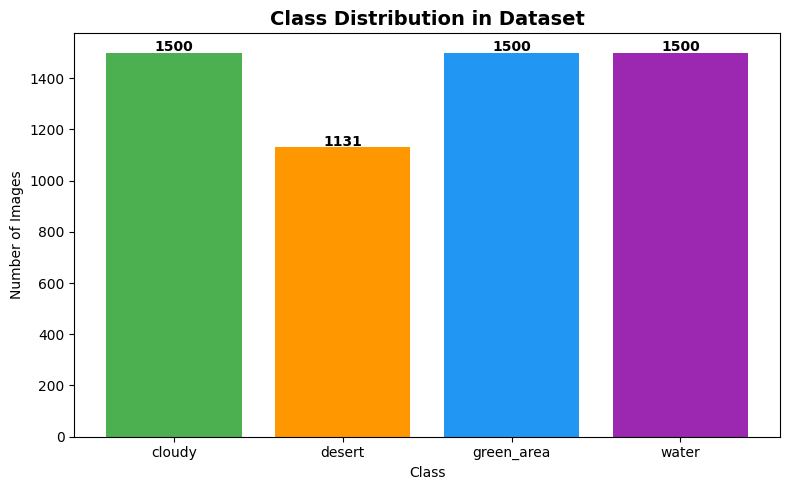

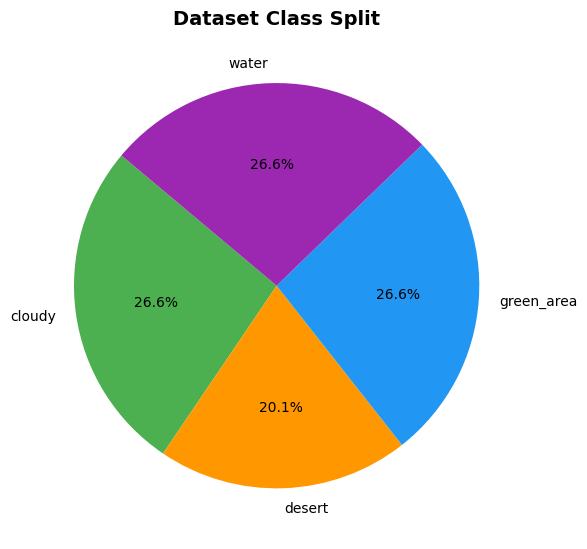

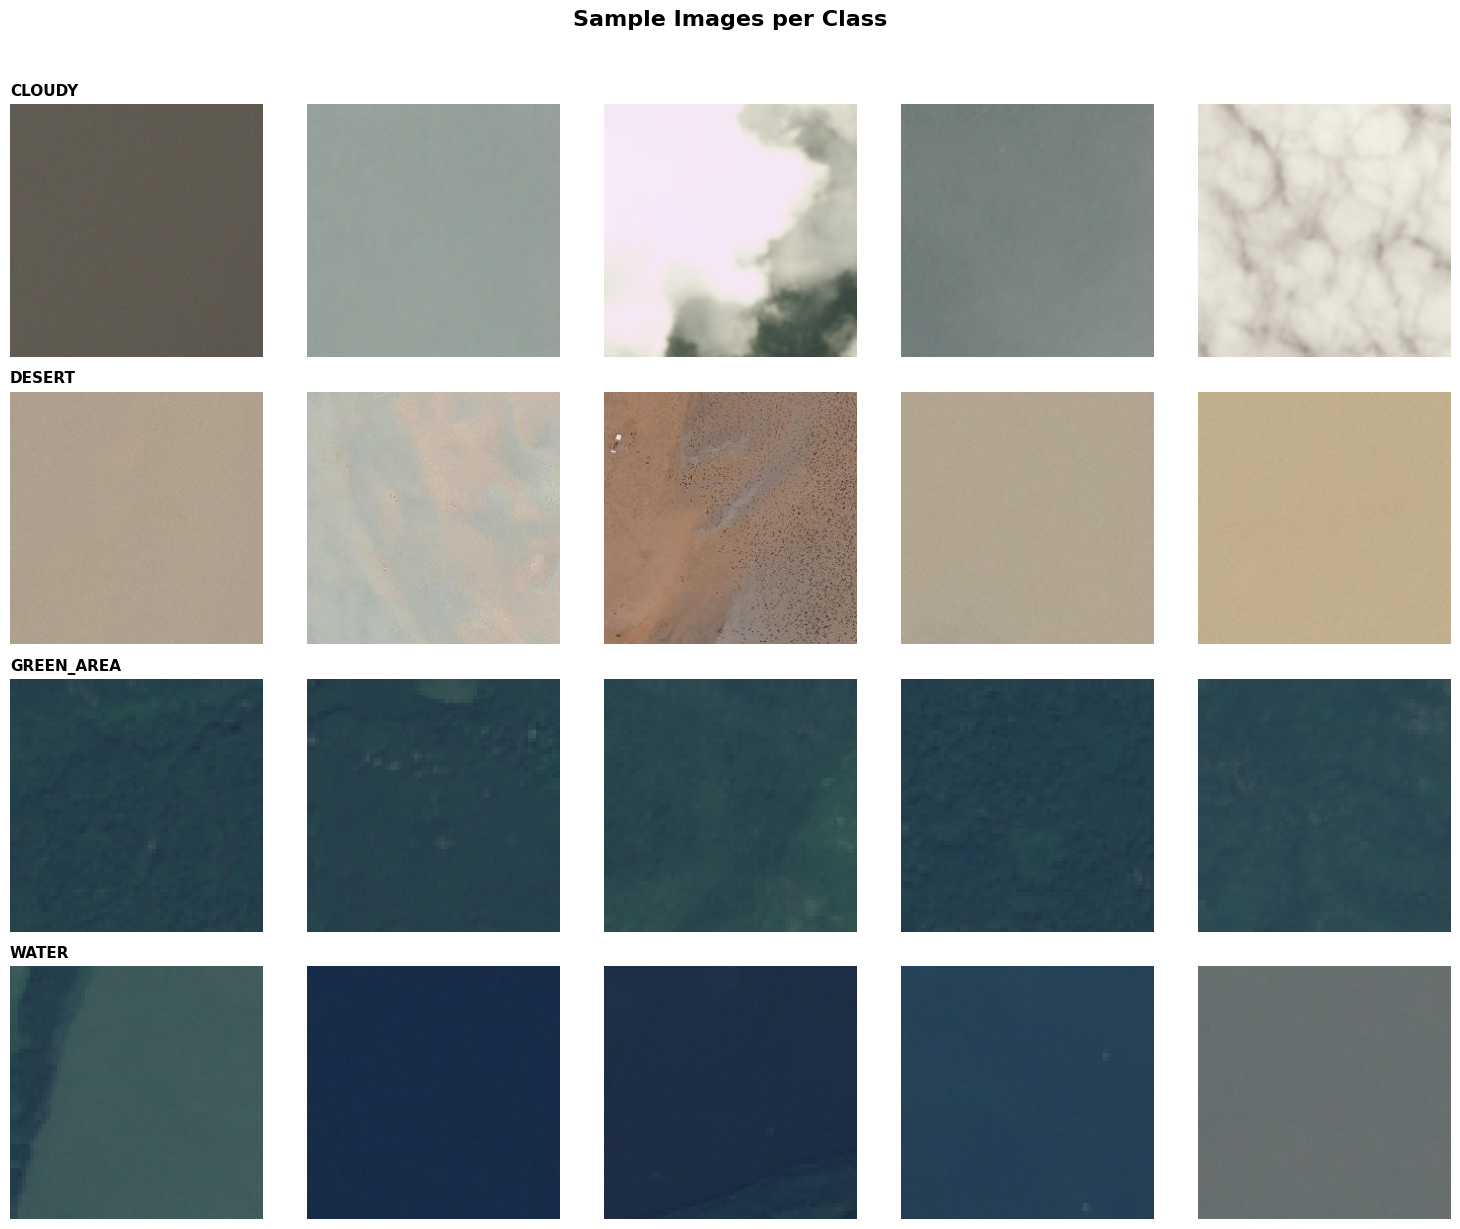

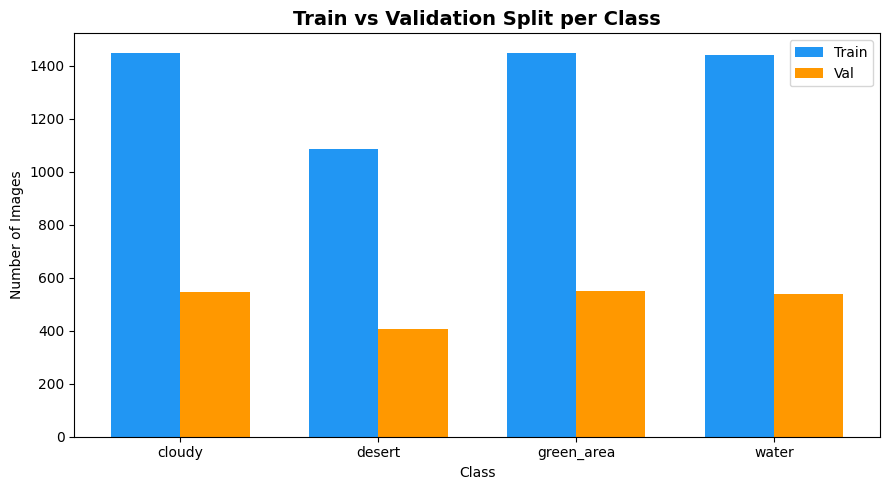

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

data_path = '/content/drive/MyDrive/Satellite_Project/extracted_data/data'
classes = os.listdir(data_path)

# ── 1. Class Distribution Bar Chart ──────────────────────────────
class_counts = {}
for cls in classes:
    class_counts[cls] = len(os.listdir(os.path.join(data_path, cls)))

plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(), color=['#4CAF50', '#FF9800', '#2196F3', '#9C27B0'])
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Images')
for bar, val in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. Pie Chart ──────────────────────────────────────────────────
plt.figure(figsize=(6, 6))
plt.pie(class_counts.values(), labels=class_counts.keys(),
        autopct='%1.1f%%', colors=['#4CAF50', '#FF9800', '#2196F3', '#9C27B0'],
        startangle=140)
plt.title('Dataset Class Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Sample Images Grid (5 per class) ──────────────────────────
fig, axes = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))
fig.suptitle('Sample Images per Class', fontsize=16, fontweight='bold', y=1.02)

for row, cls in enumerate(classes):
    cls_path = os.path.join(data_path, cls)
    images = random.sample(os.listdir(cls_path), 5)
    for col, img_name in enumerate(images):
        img = mpimg.imread(os.path.join(cls_path, img_name))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls.upper(), fontsize=11, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()

# ── 4. Train/Val Split Comparison ────────────────────────────────
train_path = '/content/drive/MyDrive/Satellite_Project/extracted_data/train'
val_path   = '/content/drive/MyDrive/Satellite_Project/extracted_data/val'

train_counts = {cls: len(os.listdir(os.path.join(train_path, cls))) for cls in os.listdir(train_path)}
val_counts   = {cls: len(os.listdir(os.path.join(val_path, cls)))   for cls in os.listdir(val_path)}

x = range(len(train_counts))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar([i - width/2 for i in x], train_counts.values(), width, label='Train', color='#2196F3')
plt.bar([i + width/2 for i in x], val_counts.values(),   width, label='Val',   color='#FF9800')
plt.xticks(x, train_counts.keys())
plt.title('Train vs Validation Split per Class', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.legend()
plt.tight_layout()
plt.show()

Creating CNN model

In [36]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
import tensorflow as tf

conv_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
conv_base.trainable = False

x = conv_base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(4, activation='softmax')(x)

model = Model(inputs=conv_base.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [37]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [40]:
# Training
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=15,
    validation_data=validate_generator,
    validation_steps=len(validate_generator),
    callbacks = [early_stopping]
)

Epoch 1/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.7015 - loss: 0.7245 - val_accuracy: 0.9446 - val_loss: 0.1872
Epoch 2/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 75s 880ms/step - accuracy: 0.9017 - loss: 0.2889 - val_accuracy: 0.9677 - val_loss: 0.1046
Epoch 3/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 74s 870ms/step - accuracy: 0.9253 - loss: 0.2179 - val_accuracy: 0.9735 - val_loss: 0.0969
Epoch 4/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 74s 865ms/step - accuracy: 0.9428 - loss: 0.1741 - val_accuracy: 0.9814 - val_loss: 0.0574
Epoch 5/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 72s 847ms/step - accuracy: 0.9506 - loss: 0.1545 - val_accuracy: 0.9882 - val_loss: 0.0416
Epoch 6/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 72s 849ms/step - accuracy: 0.9559 - loss: 0.1439 - val_accuracy: 0.9833 - val_loss: 0.0546
Epoch 7/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 71s 835ms/step - accuracy: 0.9596 - loss: 0.1374 - val_accuracy: 0.9878 - val_loss: 0.0453
Epoch 8/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 71s 834ms/step - accuracy: 0.9637 - loss: 0.1179 - val_accura

Fine tuning to update accuracy

In [41]:
conv_base.trainable = True
for layer in conv_base.layers[:-10]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(train_generator,
          epochs = 10,
          validation_data = validate_generator,
          callbacks = callbacks)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 937ms/step - accuracy: 0.7502 - loss: 0.9336
Epoch 1: val_accuracy improved from None to 0.95492, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.8168 - loss: 0.5965 - val_accuracy: 0.9549 - val_loss: 0.1252 - learning_rate: 1.0000e-05
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 835ms/step - accuracy: 0.9084 - loss: 0.2690
Epoch 2: val_accuracy improved from 0.95492 to 0.97550, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 75s 886ms/step - accuracy: 0.9190 - loss: 0.2350 - val_accuracy: 0.9755 - val_loss: 0.0834 - learning_rate: 1.0000e-05
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.9392 - loss: 0.1816
Epoch 3: val_accuracy improved from 0.97550 to 0.97844, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 77s 9

32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 289ms/step
              precision    recall  f1-score   support

      cloudy       0.26      0.25      0.26       547
      desert       0.19      0.19      0.19       406
  green_area       0.26      0.26      0.26       549
       water       0.23      0.24      0.24       539

    accuracy                           0.24      2041
   macro avg       0.23      0.23      0.23      2041
weighted avg       0.24      0.24      0.24      2041



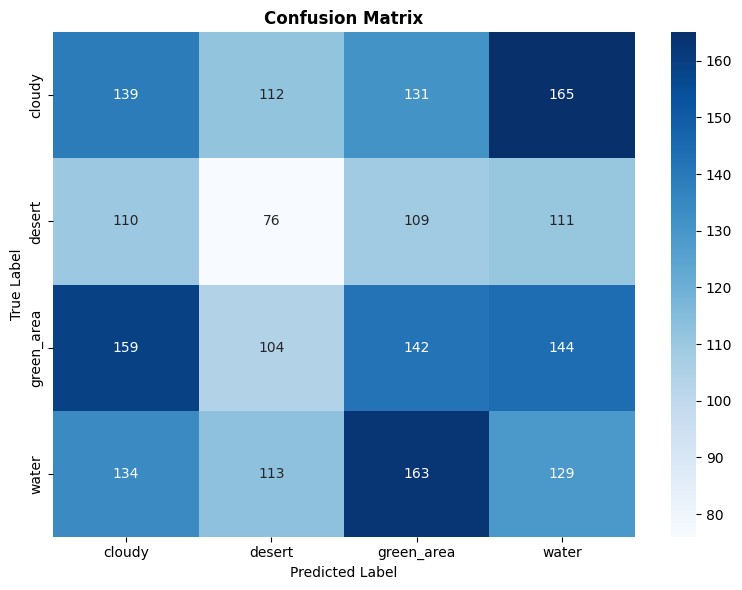

In [44]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Get predictions
validate_generator.reset()
preds = model.predict(validate_generator)
pred_classes = np.argmax(preds, axis=1)
true_classes = validate_generator.classes
class_names = list(validate_generator.class_indices.keys())

# Classification report
print(classification_report(true_classes, pred_classes, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Test on random img

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


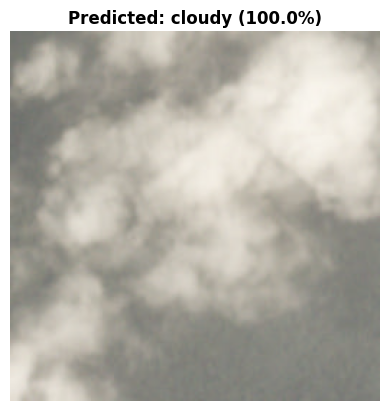

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


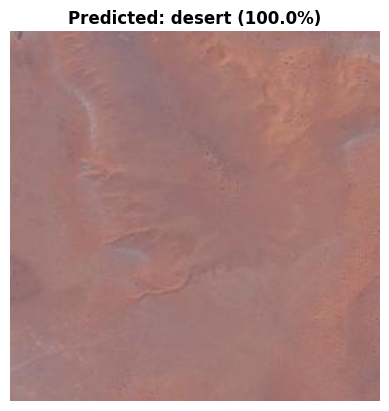

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


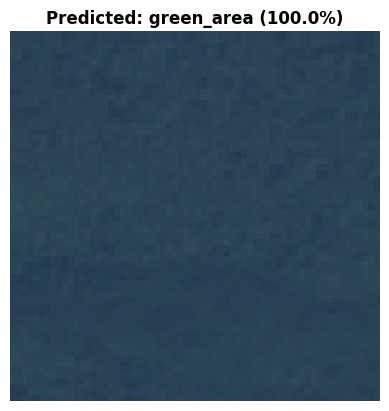

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


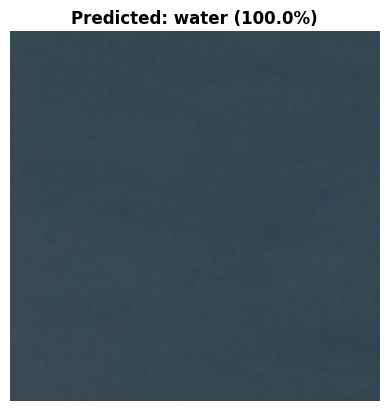

In [47]:
import random
from tensorflow.keras.preprocessing import image

def predict_single(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    confidence = np.max(preds) * 100
    predicted = class_names[np.argmax(preds)]

    plt.imshow(image.load_img(img_path))
    plt.title(f'Predicted: {predicted} ({confidence:.1f}%)', fontweight='bold')
    plt.axis('off')
    plt.show()

# Test 5 random val images
for cls in class_names:
    cls_path = f'/content/extracted_data/val/{cls}'
    img_path = os.path.join(cls_path, random.choice(os.listdir(cls_path)))
    predict_single(img_path)

In [48]:
# MOdel summary
model.summary()


trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
total     = sum([tf.size(w).numpy() for w in model.weights])
print(f"\nTrainable params : {trainable:,}")
print(f"Total params     : {total:,}")

Model: "functional_56"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 4,240,398 (16.18 MB)

 Trainable params: 904,964 (3.45 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

 Optimizer params: 1,809,930 (6.90 MB)


Trainable params : 904,964
Total params     : 2,430,468


Evaluate validation set

In [49]:
loss, accuracy = model.evaluate(validate_generator)
print(f"\nFinal Val Loss     : {loss:.4f}")
print(f"Final Val Accuracy : {accuracy*100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - accuracy: 0.9912 - loss: 0.0304

Final Val Loss     : 0.0304
Final Val Accuracy : 99.12%


Check for Misclassified Images

Total misclassified: 1555 / 2041


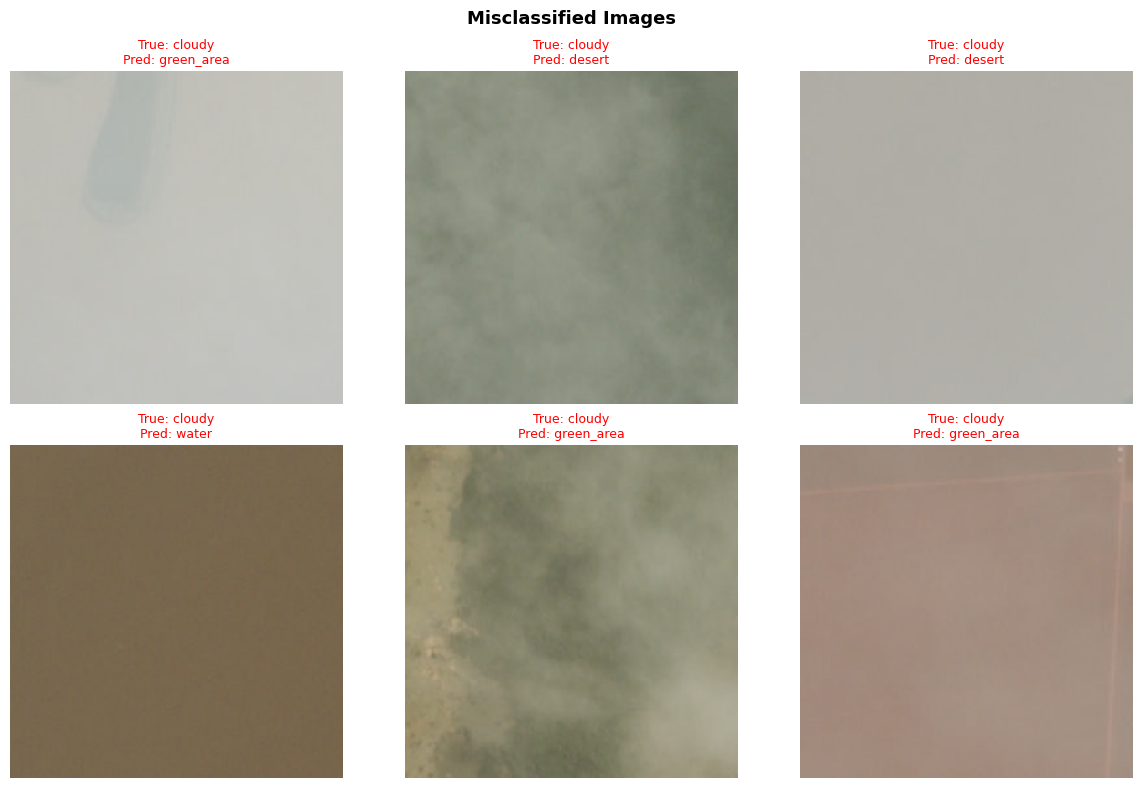

In [51]:
misclassified = np.where(pred_classes != true_classes)[0]
print(f"Total misclassified: {len(misclassified)} / {len(true_classes)}")

# Show first 6 misclassified
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, idx in enumerate(misclassified[:6]):
    img_path = validate_generator.filepaths[idx]
    img = image.load_img(img_path, target_size=(224, 224))
    axes[i].imshow(img)
    axes[i].set_title(
        f'True: {class_names[true_classes[idx]]}\nPred: {class_names[pred_classes[idx]]}',
        color='red', fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('Misclassified Images', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [53]:
import json

# Save model
model.save('satellite_classifier_final.keras')

# Save class indices
with open('class_indices.json', 'w') as f:
    json.dump(validate_generator.class_indices, f)

# Save training info
info = {
    'model'        : 'MobileNetV2 + Fine-tuning',
    'input_size'   : '224x224',
    'num_classes'  : 4,
    'class_names'  : class_names,
    'final_val_acc': float(accuracy),
    'final_val_loss': float(loss),
    'total_params' : int(total)
}
with open('model_info.json', 'w') as f:
    json.dump(info, f, indent=4)

print("Model, class indices and info saved!")

Model, class indices and info saved!
